In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/drive/MyDrive/data /content/

In [ ]:
# =========================
# LOAD DATA DARI CSV
# =========================

IMG_SIZE = 128

def load_data(csv_path, base_path):
    df = pd.read_csv(csv_path)

    images = []
    masks = []

    for i in range(len(df)):
        img_file = df.iloc[i]['Image']
        mask_file = df.iloc[i]['Mask']

        img_path = os.path.join(base_path, "Image", img_file)
        mask_path = os.path.join(base_path, "Mask", mask_file)

        # load image
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # load mask
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0

        # 🔥 penting: ubah jadi biner (0 atau 1)
        mask = (mask > 0.5).astype(np.float32)

        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

X, y = load_data(
    "/content/data/metadata.csv",
    "/content/data"
)

print("Shape:", X.shape, y.shape)

Shape: (290, 128, 128, 3) (290, 128, 128, 1)


In [ ]:
# =========================
# SPLIT TRAIN & TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =========================
# METRICS UNTUK JURNAL
# =========================

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    return (2. * K.sum(y_true_f * y_pred_f) + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

def iou_coef(y_true, y_pred):
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + 1) / (union + 1)

def precision_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1-y_true) * y_pred)
    return tp / (tp + fp + K.epsilon())

def recall_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(y_true * y_pred)
    fn = K.sum(y_true * (1-y_pred))
    return tp / (tp + fn + K.epsilon())

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [ ]:
# =========================
# MODEL U-NET
# =========================

from tensorflow.keras import layers, Model

def build_unet():
    inputs = layers.Input((128,128,3))

    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    u4 = layers.UpSampling2D()(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128,3,activation='relu',padding='same')(u4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64,3,activation='relu',padding='same')(u5)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c5)

    return Model(inputs, outputs)

model_unet = build_unet()

In [ ]:
# =========================
# MODEL SEGNET
# =========================

def build_segnet():
    inputs = layers.Input((128,128,3))

    x = layers.Conv2D(64,3,padding='same',activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128,3,padding='same',activation='relu')(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64,3,padding='same',activation='relu')(x)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(x)

    return Model(inputs, outputs)

model_segnet = build_segnet()

In [ ]:
# =========================
# COMPILE MODEL
# =========================

model_unet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef, iou_coef, precision_m, recall_m, f1_m]
)

model_segnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef, iou_coef, precision_m, recall_m, f1_m]
)

In [ ]:
# =========================
# TRAIN MODEL
# =========================

history_unet = model_unet.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=8
)

history_segnet = model_segnet.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=8
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 319ms/step - accuracy: 0.6220 - dice_coef: 0.4434 - f1_m: 0.2302 - iou_coef: 0.2855 - loss: 0.6198 - precision_m: 0.3584 - recall_m: 0.2013 - val_accuracy: 0.7161 - val_dice_coef: 0.4793 - val_f1_m: 0.5187 - val_iou_coef: 0.3157 - val_loss: 0.5390 - val_precision_m: 0.8292 - val_recall_m: 0.3974
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.7820 - dice_coef: 0.5549 - f1_m: 0.6862 - iou_coef: 0.3888 - loss: 0.5036 - precision_m: 0.7907 - recall_m: 0.6503 - val_accuracy: 0.7903 - val_dice_coef: 0.6272 - val_f1_m: 0.7208 - val_iou_coef: 0.4581 - val_loss: 0.4698 - val_precision_m: 0.8085 - val_recall_m: 0.6682
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8042 - dice_coef: 0.6439 - f1_m: 0.7426 - iou_coef: 0.4774 - loss: 0.4423 - precision_m: 0.7854 - recall_m: 0.7224 - val_accuracy: 0.7907 - val_dice_coef: 0.6271 - val_f1_m: 0.6862 - val_iou_coef: 0.4592 - val_loss: 0.4357 - val_precision_m: 0.8676 - val_reca

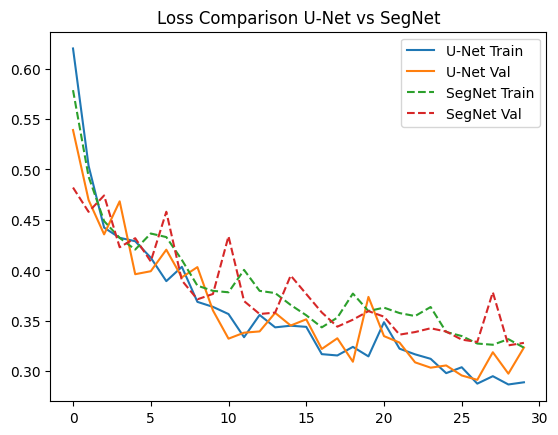

In [ ]:
plt.figure()
plt.plot(history_unet.history['loss'], label='U-Net Train')
plt.plot(history_unet.history['val_loss'], label='U-Net Val')

plt.plot(history_segnet.history['loss'], '--', label='SegNet Train')
plt.plot(history_segnet.history['val_loss'], '--', label='SegNet Val')

plt.title("Loss Comparison U-Net vs SegNet")
plt.legend()
plt.show()

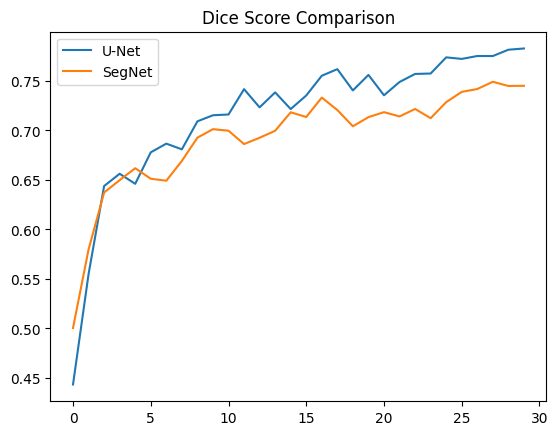

In [ ]:
plt.figure()
plt.plot(history_unet.history['dice_coef'], label='U-Net')
plt.plot(history_segnet.history['dice_coef'], label='SegNet')

plt.title("Dice Score Comparison")
plt.legend()
plt.show()

In [ ]:
# =========================
# PREDIKSI
# =========================
pred_unet = model_unet.predict(X_test)
pred_segnet = model_segnet.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 10s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


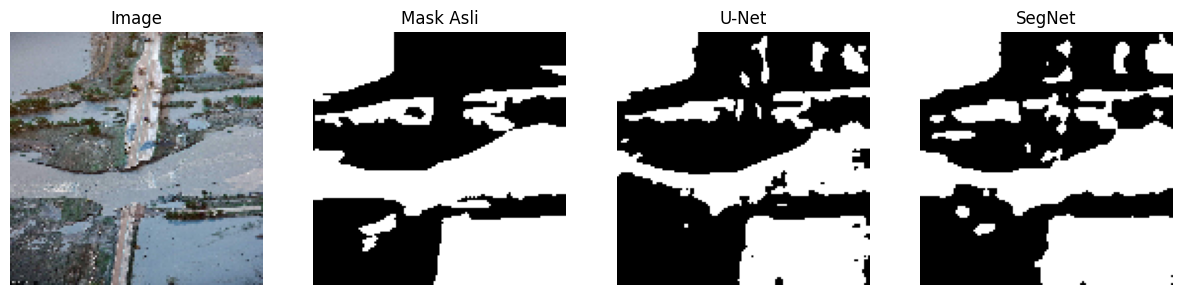

In [ ]:
# =========================
# VISUALISASI HASIL
# =========================
import matplotlib.pyplot as plt

i = 0  # ambil data pertama

plt.figure(figsize=(15,5))

# gambar asli
plt.subplot(1,4,1)
plt.imshow(X_test[i])
plt.title("Image")
plt.axis("off")

# mask asli
plt.subplot(1,4,2)
plt.imshow(y_test[i].squeeze(), cmap='gray')
plt.title("Mask Asli")
plt.axis("off")

# hasil U-Net
plt.subplot(1,4,3)
plt.imshow((pred_unet[i] > 0.5).astype('uint8').squeeze(), cmap='gray')
plt.title("U-Net")
plt.axis("off")

# hasil SegNet
plt.subplot(1,4,4)
plt.imshow((pred_segnet[i] > 0.5).astype('uint8').squeeze(), cmap='gray')
plt.title("SegNet")
plt.axis("off")

plt.show()

In [ ]:
def show_comparison(index=0):
    img = X_test[index]
    gt = y_test[index]

    pred_unet = model_unet.predict(np.expand_dims(img, axis=0))[0]
    pred_segnet = model_segnet.predict(np.expand_dims(img, axis=0))[0]

    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth")
    plt.imshow(gt.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("U-Net Prediction")
    plt.imshow((pred_unet > 0.5).astype('uint8').squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("SegNet Prediction")
    plt.imshow((pred_segnet > 0.5).astype('uint8').squeeze(), cmap='gray')
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step


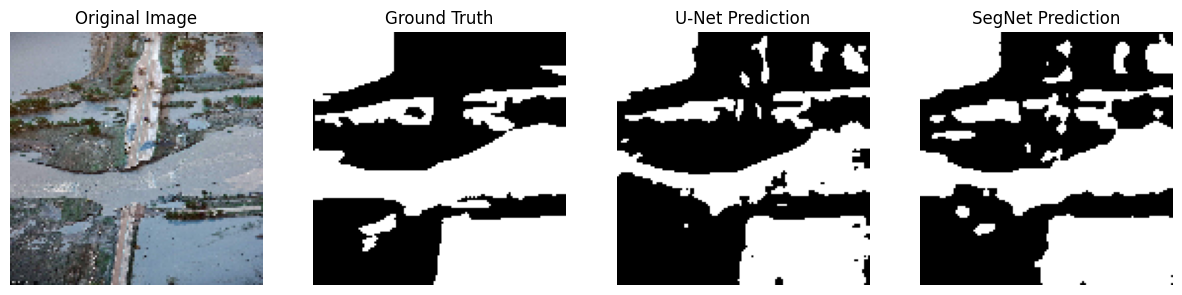

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


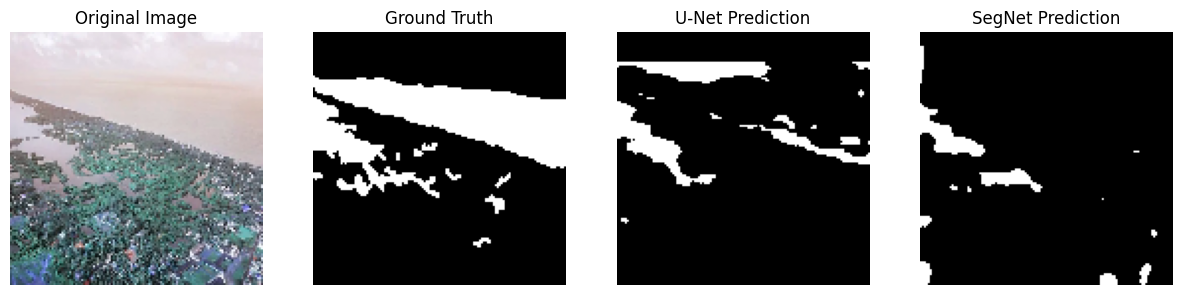

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


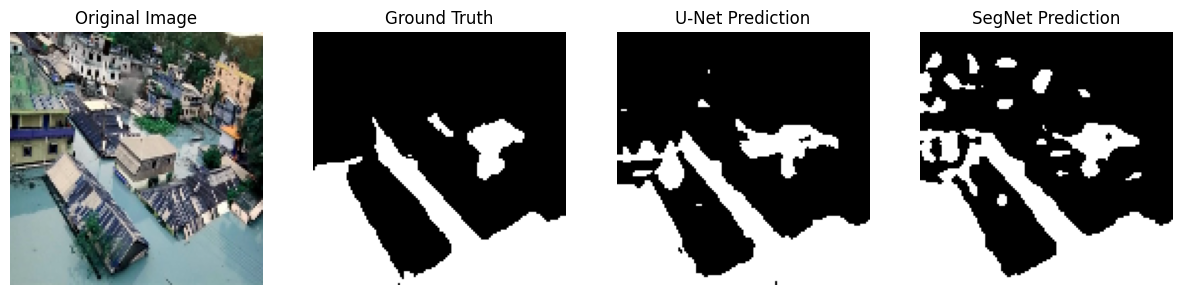

In [ ]:
show_comparison(0)
show_comparison(1)
show_comparison(5)

In [ ]:
def overlay_comparison(index=0):
    img = (X_test[index] * 255).astype(np.uint8)

    # prediksi
    pred_unet = model_unet.predict(np.expand_dims(X_test[index], axis=0))[0]
    pred_segnet = model_segnet.predict(np.expand_dims(X_test[index], axis=0))[0]

    mask_unet = (pred_unet > 0.5).astype(np.uint8)
    mask_segnet = (pred_segnet > 0.5).astype(np.uint8)

    # fungsi overlay
    def apply_overlay(img, mask, color):
        color_mask = np.zeros_like(img)
        color_mask[:, :, :] = color
        alpha = 0.4

        return np.where(mask.squeeze()[:, :, None] == 1,
                        (img * (1 - alpha) + color_mask * alpha).astype(np.uint8),
                        img)

    # 🔥 beda warna biar jelas
    overlay_unet = apply_overlay(img, mask_unet, [255, 0, 0])   # merah
    overlay_segnet = apply_overlay(img, mask_segnet, [0, 0, 255]) # biru

    # =========================
    # TAMPILKAN
    # =========================
    plt.figure(figsize=(15,5))

    # gambar asli
    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    # U-Net
    plt.subplot(1,3,2)
    plt.title("U-Net Overlay")
    plt.imshow(overlay_unet)
    plt.axis("off")

    # SegNet
    plt.subplot(1,3,3)
    plt.title("SegNet Overlay")
    plt.imshow(overlay_segnet)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


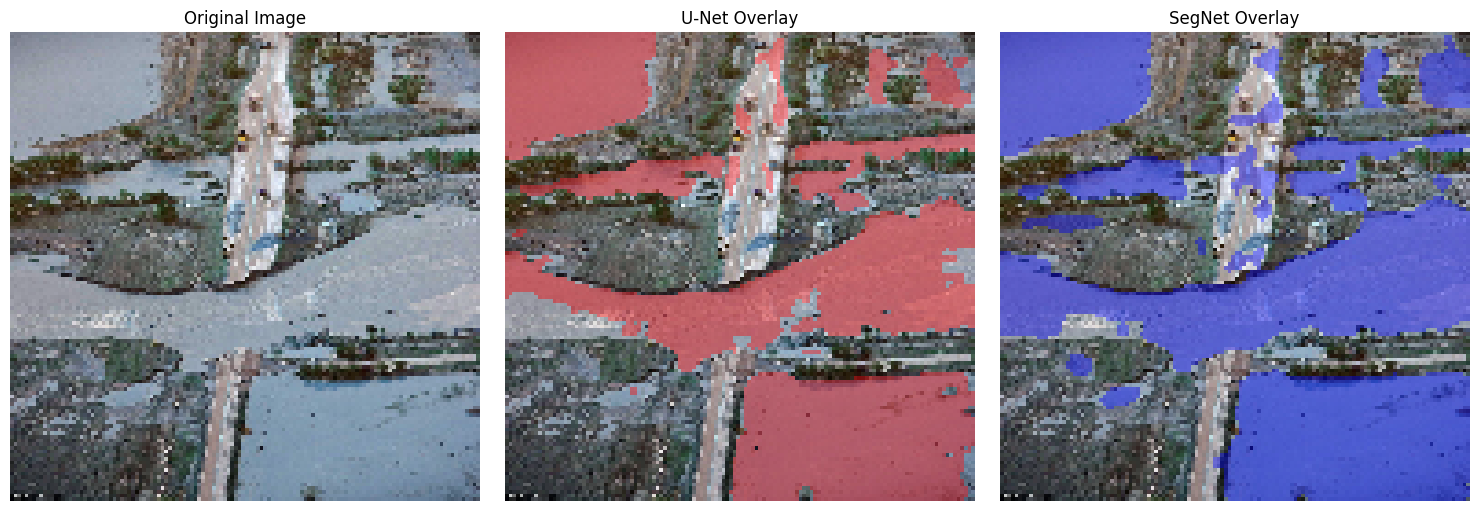

In [ ]:
    overlay_comparison(0)

In [ ]:
def plot_confusion_comparison(model1, model2, X, y):
    preds1 = model1.predict(X)
    preds2 = model2.predict(X)

    y_true = y.flatten()
    y_pred1 = (preds1 > 0.5).astype(int).flatten()
    y_pred2 = (preds2 > 0.5).astype(int).flatten()

    cm1 = confusion_matrix(y_true, y_pred1)
    cm2 = confusion_matrix(y_true, y_pred2)

    plt.figure(figsize=(12,5))

    # U-Net
    plt.subplot(1,2,1)
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Flood','Flood'],
                yticklabels=['No Flood','Flood'])
    plt.title("U-Net")

    # SegNet
    plt.subplot(1,2,2)
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds',
                xticklabels=['No Flood','Flood'],
                yticklabels=['No Flood','Flood'])
    plt.title("SegNet")

    plt.tight_layout()
    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


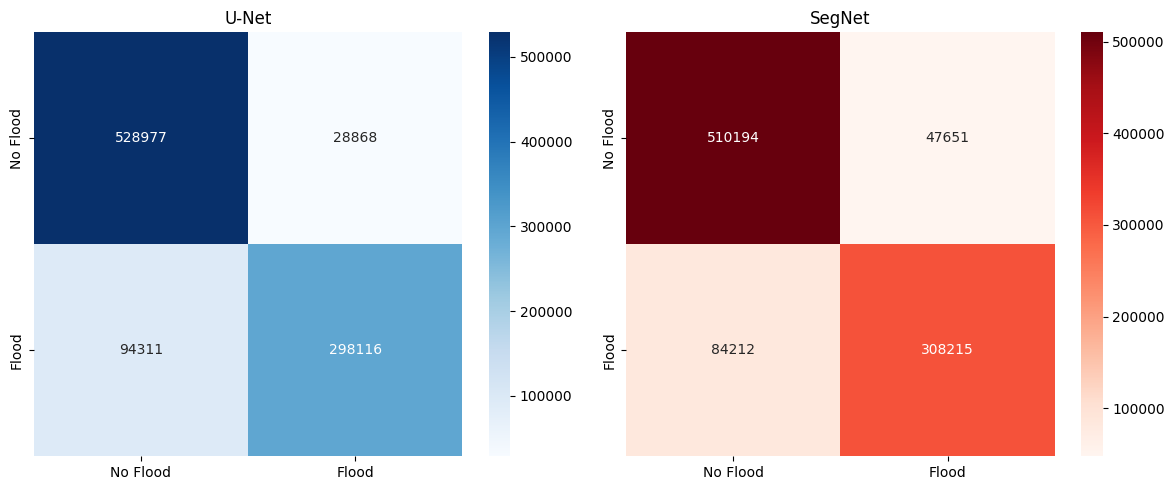

In [ ]:
plot_confusion_comparison(model_unet, model_segnet, X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


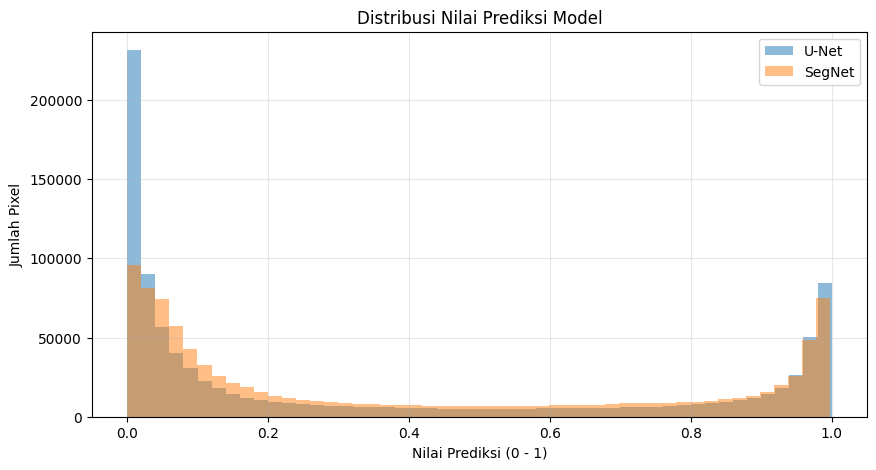

In [ ]:
preds_unet = model_unet.predict(X_test)
preds_segnet = model_segnet.predict(X_test)

plt.figure(figsize=(10,5))

plt.hist(preds_unet.flatten(), bins=50, alpha=0.5, label='U-Net')
plt.hist(preds_segnet.flatten(), bins=50, alpha=0.5, label='SegNet')

plt.title("Distribusi Nilai Prediksi Model")
plt.xlabel("Nilai Prediksi (0 - 1)")
plt.ylabel("Jumlah Pixel")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

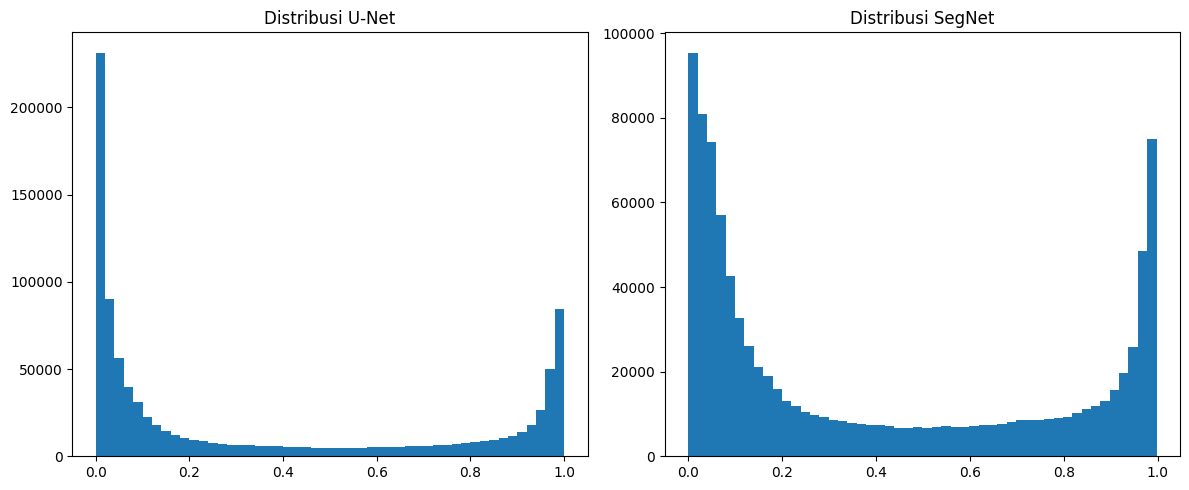

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(preds_unet.flatten(), bins=50)
plt.title("Distribusi U-Net")

plt.subplot(1,2,2)
plt.hist(preds_segnet.flatten(), bins=50)
plt.title("Distribusi SegNet")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# EVALUASI MODEL
# =========================
results_unet = model_unet.evaluate(X_test, y_test)
results_segnet = model_segnet.evaluate(X_test, y_test)

metrics = ['Loss','Accuracy','Dice','IoU','Precision','Recall','F1']

print("U-Net:", dict(zip(metrics, results_unet)))
print("SegNet:", dict(zip(metrics, results_segnet)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8704 - dice_coef: 0.7773 - f1_m: 0.8312 - iou_coef: 0.6363 - loss: 0.3235 - precision_m: 0.9130 - recall_m: 0.7632
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8612 - dice_coef: 0.7550 - f1_m: 0.8257 - iou_coef: 0.6068 - loss: 0.3282 - precision_m: 0.8682 - recall_m: 0.7872
U-Net: {'Loss': 0.3234959840774536, 'Accuracy': 0.8703750371932983, 'Dice': 0.7772620916366577, 'IoU': 0.6363083720207214, 'Precision': 0.9130067825317383, 'Recall': 0.7631963491439819, 'F1': 0.8312463760375977}
SegNet: {'Loss': 0.3281576335430145, 'Accuracy': 0.861236572265625, 'Dice': 0.7549766898155212, 'IoU': 0.6067764759063721, 'Precision': 0.8681509494781494, 'Recall': 0.7871673107147217, 'F1': 0.8256778717041016}


In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd

# =========================
# EVALUASI MODEL
# =========================
results_unet = model_unet.evaluate(X_test, y_test)
results_segnet = model_segnet.evaluate(X_test, y_test)

# daftar metric (sesuaikan urutan dengan model.compile kamu)
metrics = ['Loss','Accuracy','Dice','IoU','Precision','Recall','F1']

# =========================
# MEMBUAT TABEL PERBANDINGAN
# =========================
def create_metrics_table(results_unet, results_segnet, metrics):
    df = pd.DataFrame({
        'Metric': metrics,
        'U-Net': results_unet,
        'SegNet': results_segnet
    })

    # pembulatan angka biar rapi
    df[['U-Net','SegNet']] = df[['U-Net','SegNet']].round(4)

    # tambah kolom selisih (U-Net - SegNet)
    df['Selisih'] = (df['U-Net'] - df['SegNet']).round(4)

    return df

# =========================
# TAMPILKAN HASIL
# =========================
df_metrics = create_metrics_table(results_unet, results_segnet, metrics)

print("\n=== PERBANDINGAN KINERJA MODEL ===\n")
print(df_metrics.to_string(index=False))

# kalau di Jupyter/Colab, tampilkan lebih bagus
df_metrics

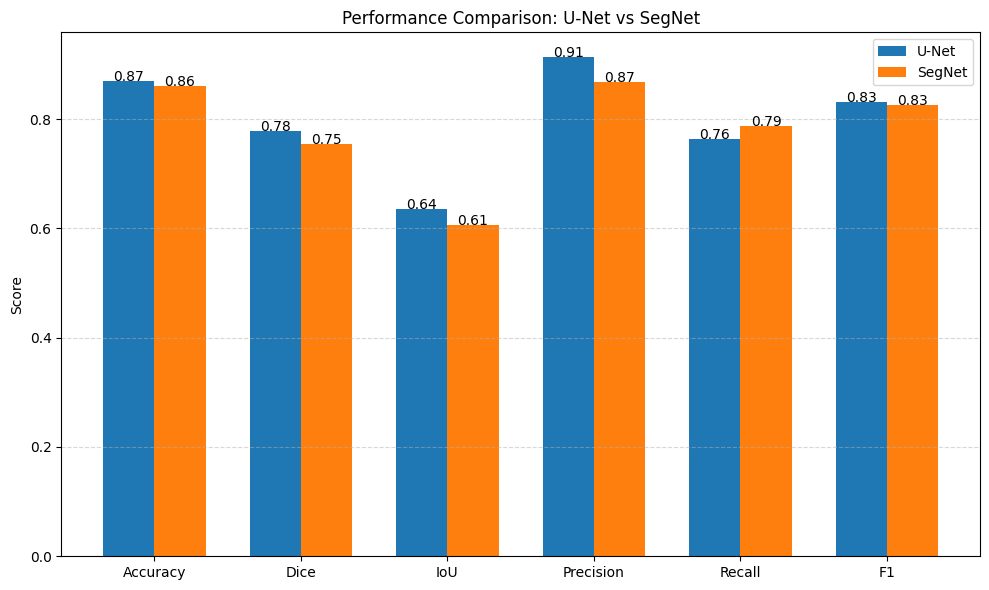

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = metrics[1:]  # tanpa loss
unet_values = results_unet[1:]
segnet_values = results_segnet[1:]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, unet_values, width, label='U-Net')
bars2 = plt.bar(x + width/2, segnet_values, width, label='SegNet')

# angka di atas bar
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Performance Comparison: U-Net vs SegNet")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
def show_multiple_advanced(n=3):
    n = min(n, len(X_test))

    preds_unet = model_unet.predict(X_test[:n])
    preds_segnet = model_segnet.predict(X_test[:n])

    plt.figure(figsize=(18, n*4))

    for i in range(n):
        img = (X_test[i] * 255).astype('uint8')
        gt = y_test[i].squeeze()

        pred_u = (preds_unet[i] > 0.5).astype('uint8').squeeze()
        pred_s = (preds_segnet[i] > 0.5).astype('uint8').squeeze()

        # overlay function
        def overlay(img, mask, color):
            color_mask = np.zeros_like(img)
            color_mask[:] = color
            alpha = 0.4
            return np.where(mask[:,:,None]==1,
                            (img*(1-alpha)+color_mask*alpha).astype('uint8'),
                            img)

        overlay_u = overlay(img, pred_u, [255,0,0])   # merah
        overlay_s = overlay(img, pred_s, [0,0,255])   # biru

        # =========================
        # TAMPILKAN (5 kolom)
        # =========================

        # Image
        plt.subplot(n,5,i*5+1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        # Ground Truth
        plt.subplot(n,5,i*5+2)
        plt.imshow(gt, cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # U-Net mask
        plt.subplot(n,5,i*5+3)
        plt.imshow(pred_u, cmap='gray')
        plt.title("U-Net Mask")
        plt.axis("off")

        # SegNet mask
        plt.subplot(n,5,i*5+4)
        plt.imshow(pred_s, cmap='gray')
        plt.title("SegNet Mask")
        plt.axis("off")

        # Overlay comparison
        plt.subplot(n,5,i*5+5)
        combined = overlay_u.copy()
        combined[pred_s==1] = [0,0,255]  # biru
        plt.imshow(combined)
        plt.title("Overlay Compare")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step


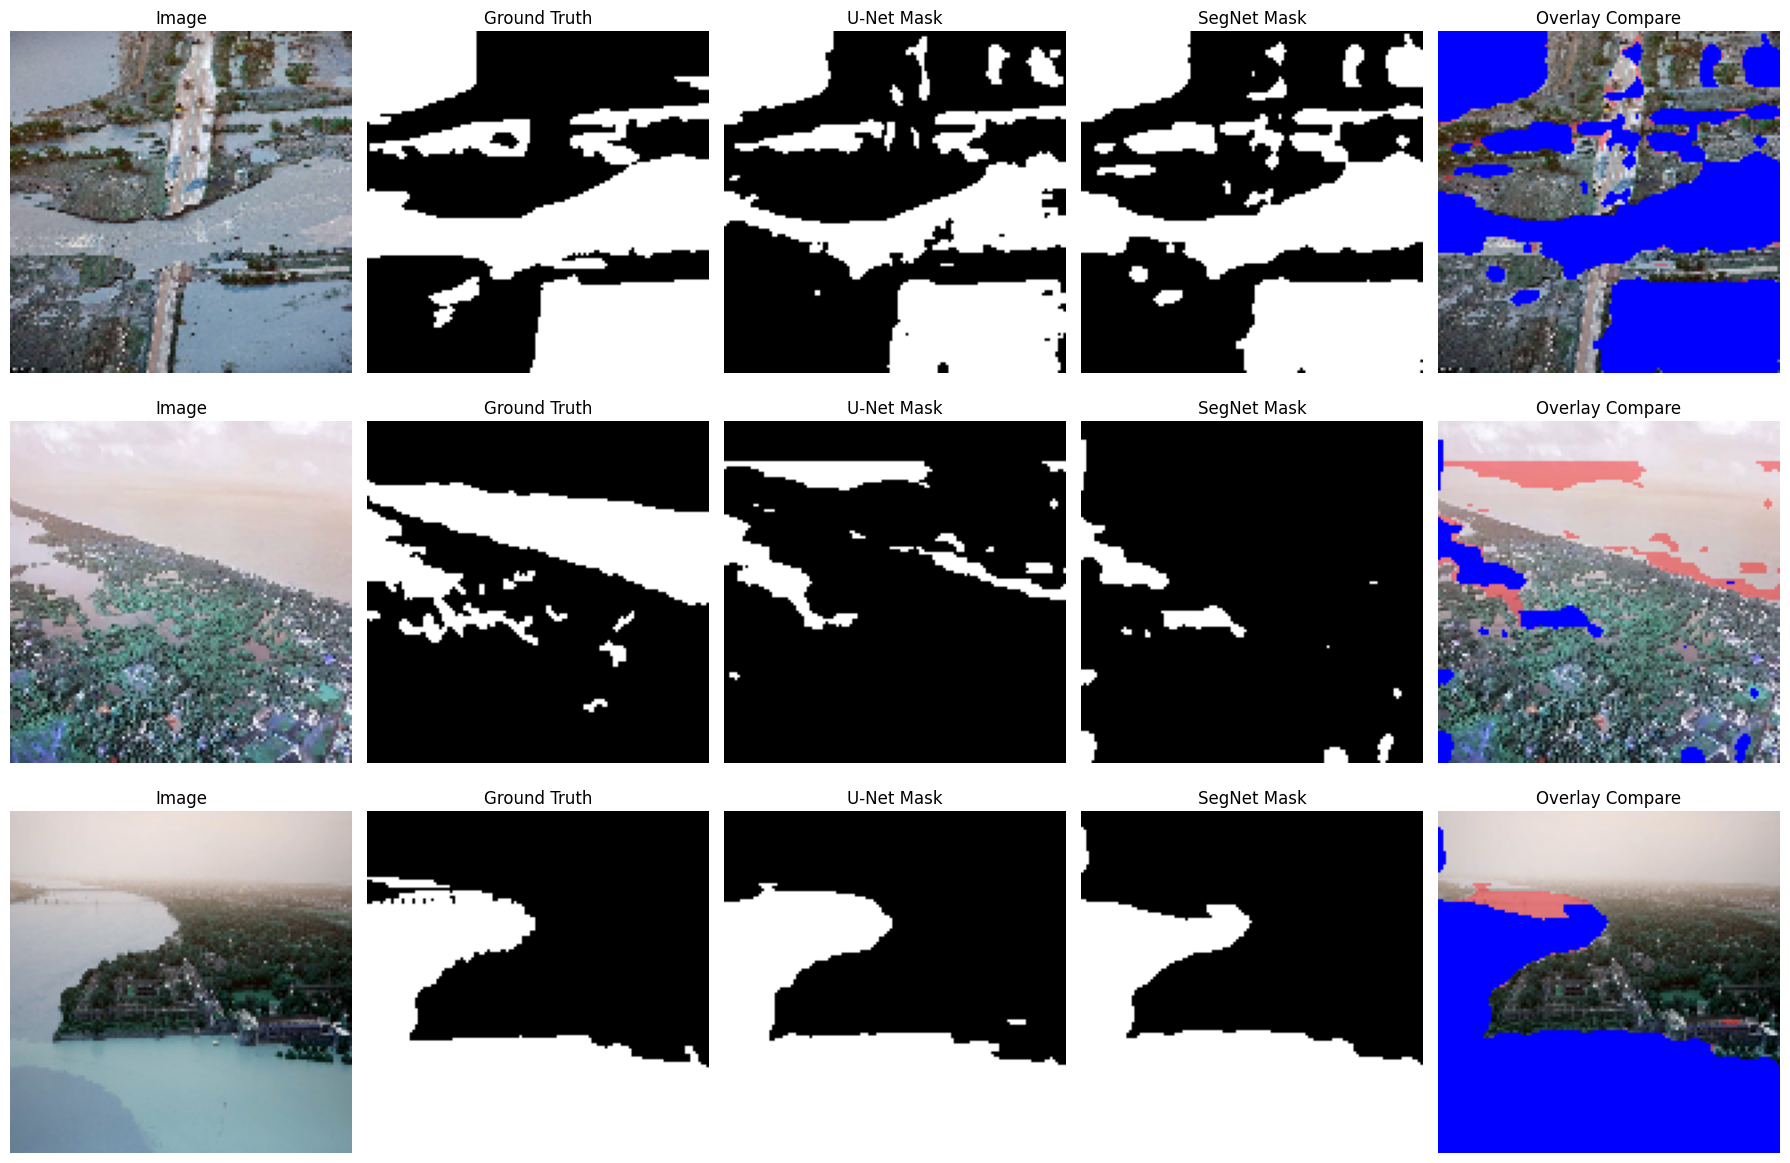

In [ ]:
show_multiple_advanced(3)

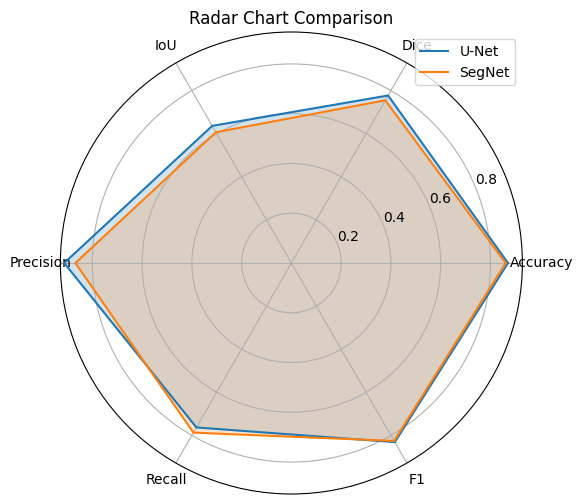

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Accuracy','Dice','IoU','Precision','Recall','F1']

unet = np.array(results_unet[1:])
segnet = np.array(results_segnet[1:])

# sudut (TANPA penutup)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

# tambahkan titik pertama ke akhir (biar nutup lingkaran)
unet_plot = np.concatenate((unet, [unet[0]]))
segnet_plot = np.concatenate((segnet, [segnet[0]]))
angles_plot = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

# plot
ax.plot(angles_plot, unet_plot, label='U-Net')
ax.fill(angles_plot, unet_plot, alpha=0.2)

ax.plot(angles_plot, segnet_plot, label='SegNet')
ax.fill(angles_plot, segnet_plot, alpha=0.2)

# 🔥 pakai angles asli untuk label
ax.set_thetagrids(angles * 180/np.pi, labels)

plt.title("Radar Chart Comparison")
plt.legend()
plt.show()

In [ ]:
def show_multiple(n=5):
    plt.figure(figsize=(15, n*3))

    for i in range(n):
        img = X_test[i]
        gt = y_test[i]

        pred = model_unet.predict(np.expand_dims(img, axis=0))[0]

        plt.subplot(n,3,i*3+1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n,3,i*3+2)
        plt.imshow(gt.squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n,3,i*3+3)
        plt.imshow((pred>0.5).astype('uint8').squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


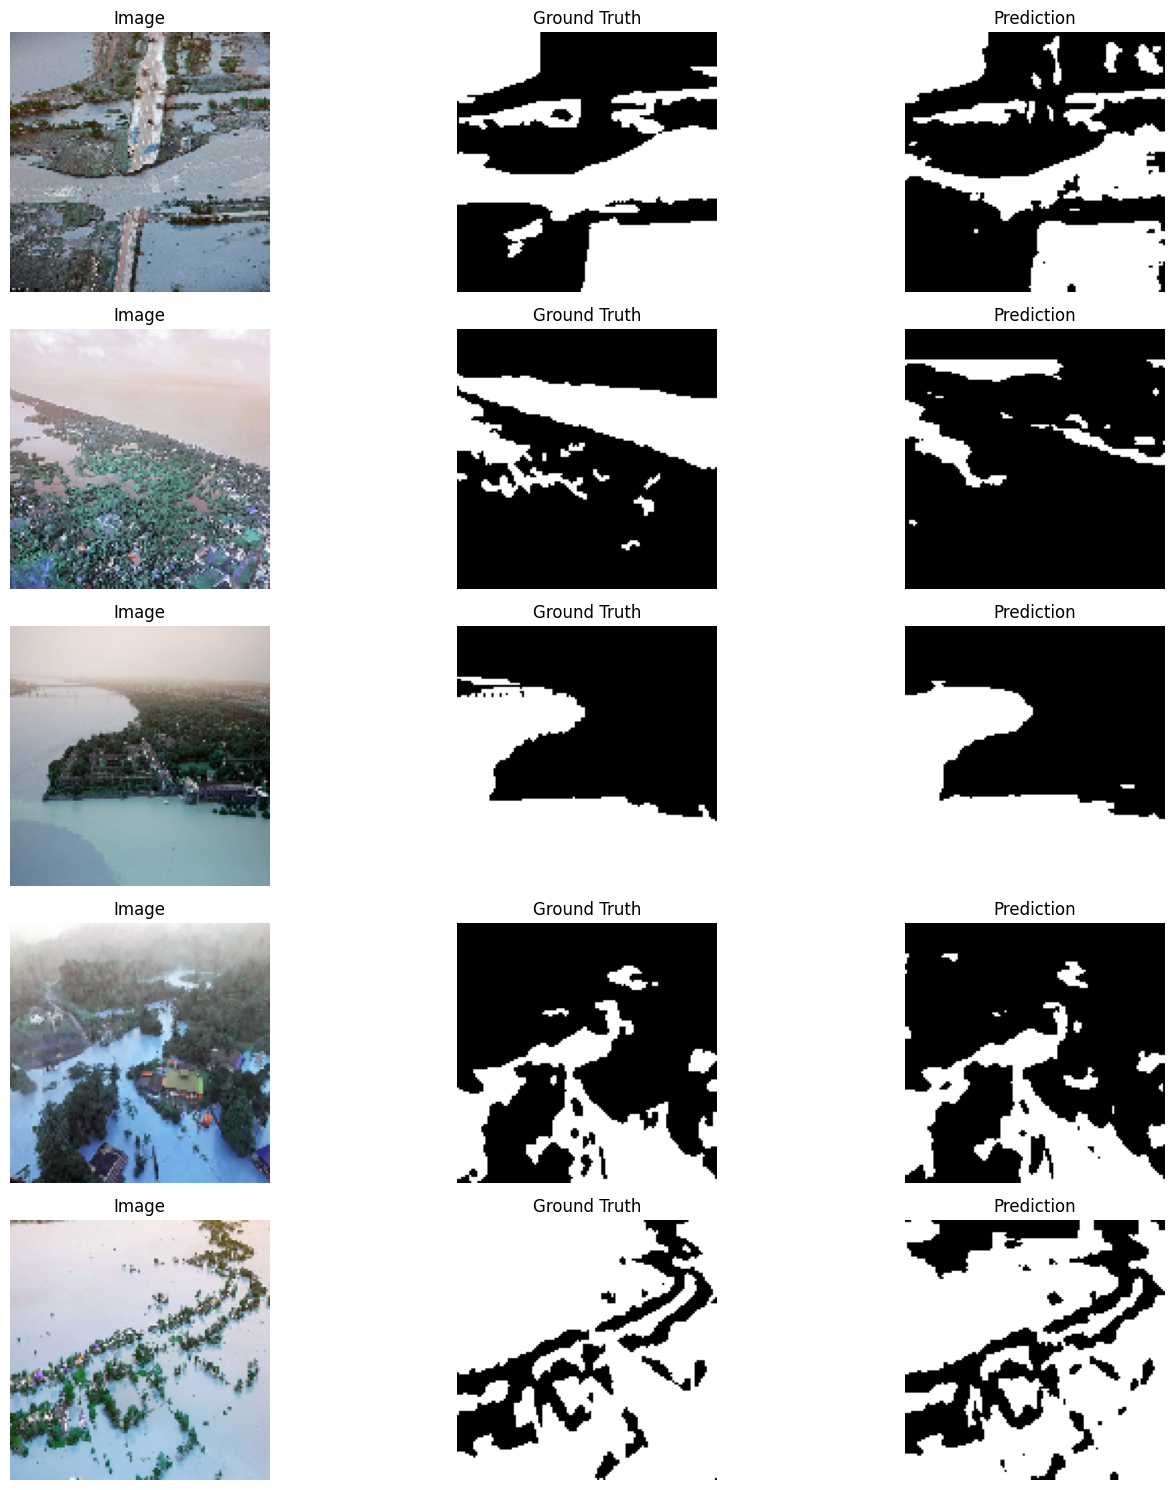

In [ ]:
show_multiple(5)

In [ ]:
# =========================
# SIMPAN MODEL UNTUK GUI
# =========================
model_unet.save('/content/drive/MyDrive/unet_model.h5')
model_segnet.save('/content/drive/MyDrive/segnet_model.h5')

print("Model tersimpan di Google Drive. Download kedua file .h5 ini")
print("dan taruh di folder yang sama dengan app.py sebelum deploy ke Hugging Face Spaces.")